# A kernel is a mathematical function that computes similarity between two points — often without explicitly transforming the data into higher dimensions.

Why Do We Need Kernels?

    Some data is not linearly separable in its original (low-dimensional) form.
    A linear boundary won't work in this space.
    But if we could map the data into a higher-dimensional space, it may become linearly separable.

This is where kernels come in — they let us do this mapping implicitly, and efficiently.

# Kernel Trick = Magical Feature Space Elevator

    Suppose your data lives in a 2D room where no wall (line) can separate the red and blue dots.
    The kernel trick is like pushing a button in an elevator that lifts the data into a 3D room upstairs, where now you can find a separating plane.
    The magic? You never really go upstairs — you just compute the dot product as if you did, using a kernel function!

In [ ]:
# fail case 

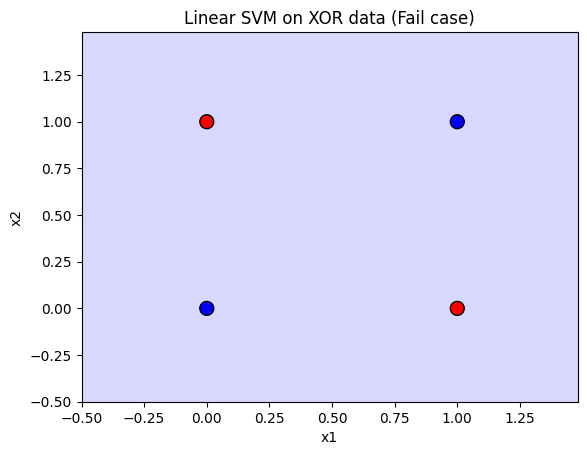

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# XOR dataset
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

# Train linear SVM
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X, y)

# Plot
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k', s=100)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

plot_decision_boundary(svm_linear, X, y, 'Linear SVM on XOR data (Fail case)')

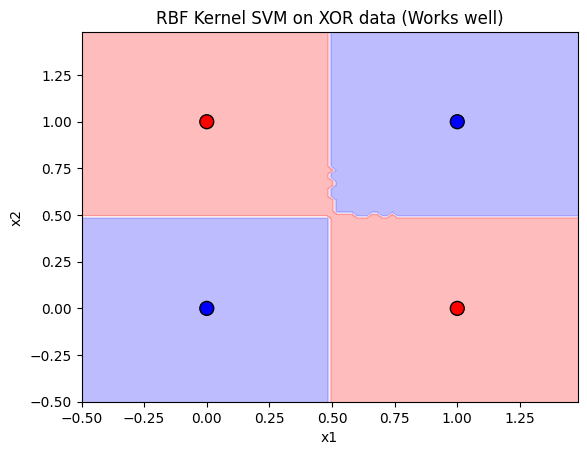

In [3]:
# answer to the above 

# svm_rbf = SVC(kernel='rbf', C=1, gamma='auto')
# svm_rbf.fit(X, y)
# plot_decision_boundary(svm_rbf, X, y, 'RBF Kernel SVM on XOR data (Works well)')

Lets see a sample 

Where, No straight line can separate them in 2D.

But in higher dimensions, they can be separated linearly.

# Non linear surface 

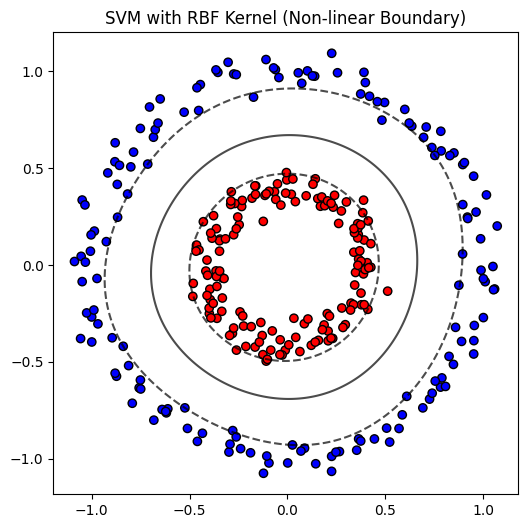

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# Generate circular data (non-linearly separable)
X, y = make_circles(n_samples=300, factor=0.4, noise=0.05, random_state=0)
y = np.where(y == 0, -1, 1)  # Map to -1 and 1

# Helper to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    
    xlim = plt.xlim()
    ylim = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 300),
                         np.linspace(ylim[0], ylim[1], 300))
    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    Z = model.decision_function(xy).reshape(xx.shape)

    plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1],
                linestyles=['--', '-', '--'], alpha=0.7)
    plt.title(title)
    plt.show()

# Train with RBF kernel (nonlinear SVM)
model_rbf = SVC(kernel='rbf', C=1, gamma='scale')  # gamma controls how far influence of a single training point reaches
model_rbf.fit(X, y)
plot_decision_boundary(model_rbf, X, y, "SVM with RBF Kernel (Non-linear Boundary)")


# kernel: Radial Basis Function (Gaussian) 
# The RBF kernel maps data to a higher-dimensional space, allowing SVM to learn non-linear relationships between classes

Gaussian function:
The kernel function is based on a Gaussian distribution, where the similarity between two data points is higher when they are closer together in the feature space. 


Parameter gamma:
The gamma parameter controls the influence of each training example, effectively determining the width of the Gaussian distribution. A smaller gamma creates a wider distribution, while a larger gamma creates a narrower distribution

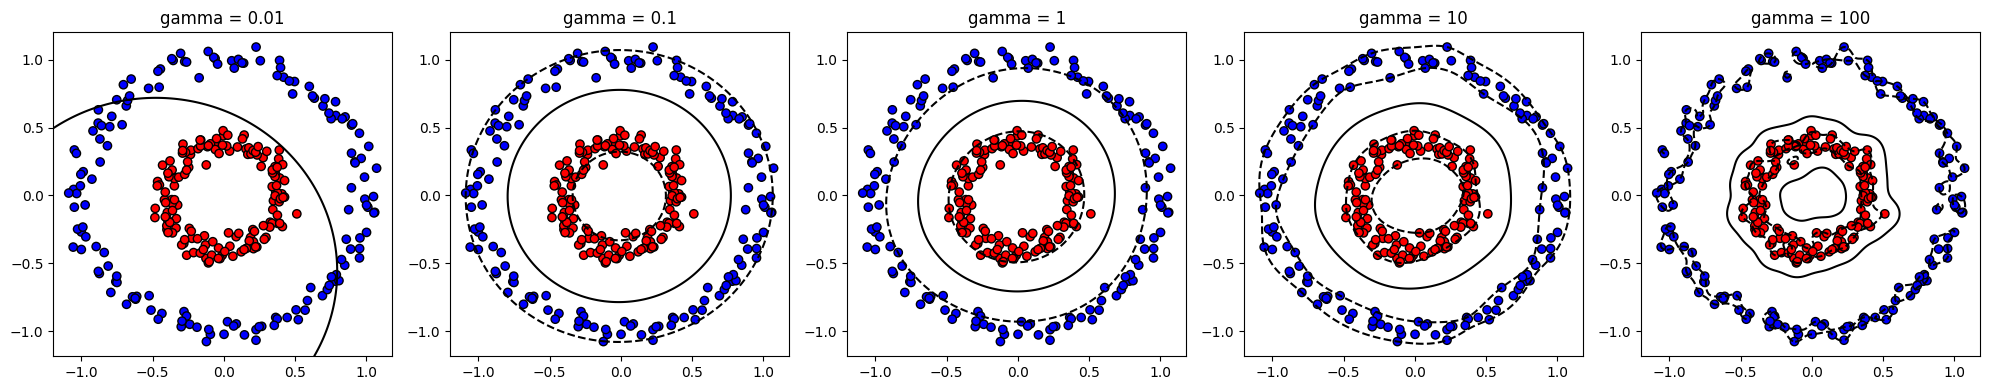

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# Some synthetic nonlinear data
X, y = make_circles(n_samples=300, factor=0.4, noise=0.05, random_state=0)
y = np.where(y == 0, -1, 1)


def plot_decision_boundary(ax, model, X, y, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 300),
                         np.linspace(ylim[0], ylim[1], 300))
    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    Z = model.decision_function(xy).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k',
               linestyles=['--', '-', '--'])
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


gamma_values = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, len(gamma_values), figsize=(20, 4))

for i, gamma in enumerate(gamma_values):
    model = SVC(kernel='rbf', C=1, gamma=gamma)
    model.fit(X, y)
    plot_decision_boundary(axes[i], model, X, y, f"gamma = {gamma}")

plt.tight_layout()
plt.show()


# polynomial kernel

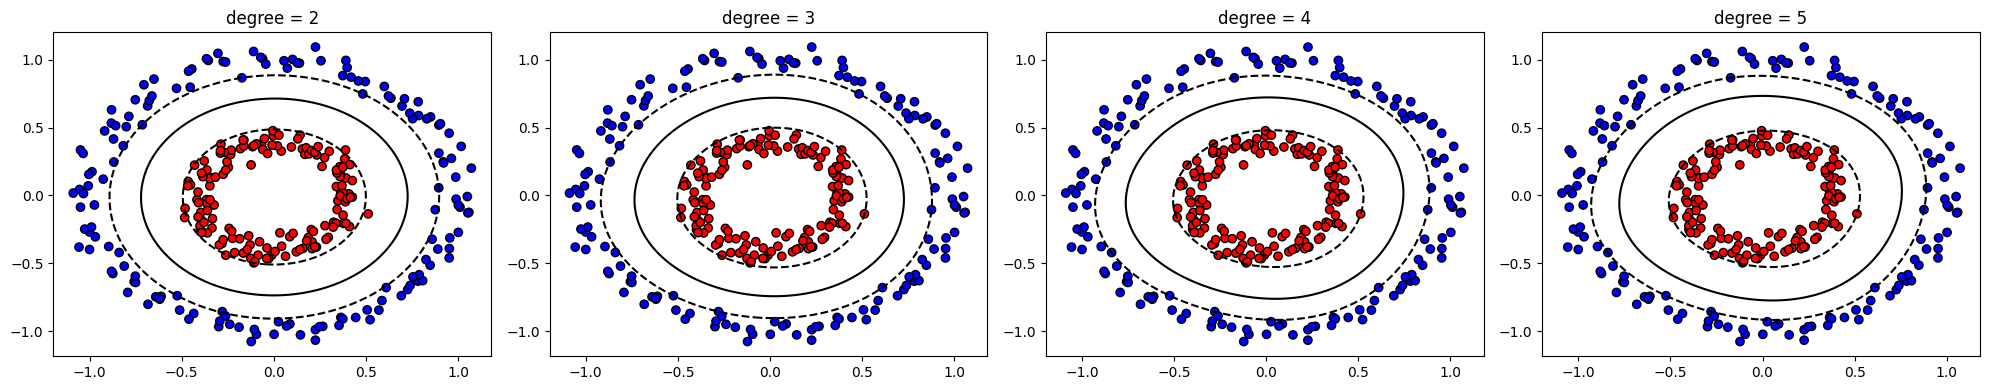

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# Some non-linear data
X, y = make_circles(n_samples=300, factor=0.4, noise=0.05, random_state=0)
y = np.where(y == 0, -1, 1)

# decision boundary
def plot_decision_boundary(ax, model, X, y, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 300),
                         np.linspace(ylim[0], ylim[1], 300))
    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    Z = model.decision_function(xy).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k',
               linestyles=['--', '-', '--'])
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# Trying different degrees
degrees = [2, 3, 4, 5]
fig, axes = plt.subplots(1, len(degrees), figsize=(20, 4))

for i, d in enumerate(degrees):
    model = SVC(kernel='poly', degree=d, C=1, gamma='scale', coef0=1)
    model.fit(X, y)
    plot_decision_boundary(axes[i], model, X, y, f"degree = {d}")

plt.tight_layout()
plt.show()


In [ ]:
# example

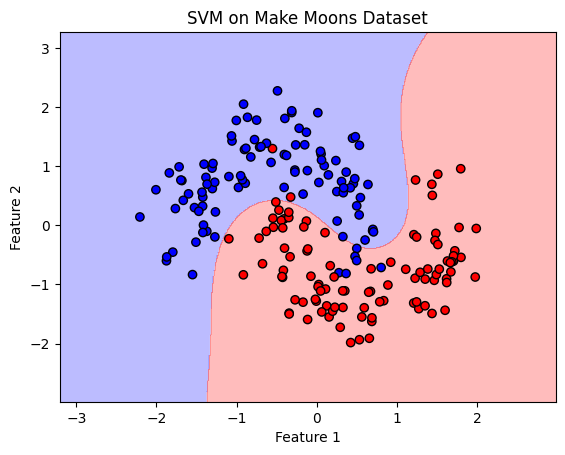

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Generate moons dataset
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train SVM with RBF kernel
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_scaled, y)

# Plot decision boundary
def plot_decision_boundary(model, X, y):
    h = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k')
    plt.title("SVM on Make Moons Dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(svm, X_scaled, y)


In [15]:
# Example

In [14]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Load data
data = load_wine()
X, y = data.data, data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with RBF kernel
svm = SVC(kernel='rbf', gamma='scale')
svm.fit(X_train_scaled, y_train)

# Predict and report
y_pred = svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=data.target_names))


              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
# example

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Load dataset from UCI URL (or replace with local file path)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Define column names as dataset has no headers
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
                "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

data = pd.read_csv(url, names=column_names)

# Step 2: Separate features and target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Train SVM classifier with RBF kernel
svm = SVC(kernel='rbf', gamma='scale', C=1)
svm.fit(X_train_scaled, y_train)

# Step 6: Predict and evaluate
y_pred = svm.predict(X_test_scaled)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix:
 [[82 17]
 [24 31]]


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80        99
           1       0.65      0.47      0.55        55

    accuracy                           0.72       154
   macro avg       0.70      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154

Confusion Matrix:
 [[85 14]
 [29 26]]


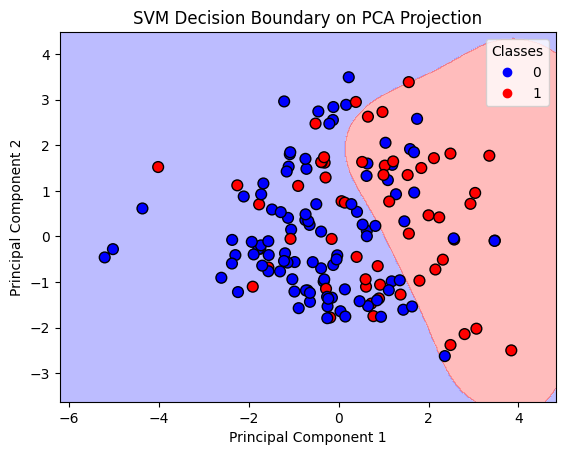

In [17]:
# SVM + PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
                "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
data = pd.read_csv(url, names=column_names)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA projection to 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train SVM on PCA features
svm = SVC(kernel='rbf', gamma='scale', C=1)
svm.fit(X_train_pca, y_train)

# Predict on test set
y_pred = svm.predict(X_test_pca)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot decision boundary function
def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.bwr, edgecolors='k', s=60)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('SVM Decision Boundary on PCA Projection')
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

plot_decision_boundary(svm, X_test_pca, y_test)


In [ ]:
# An example

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm = SVC(kernel='rbf', gamma='scale', C=1)
svm.fit(X_train_scaled, y_train)

# Predict
y_pred = svm.predict(X_test_scaled)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[41  2]
 [ 0 71]]
